# Análisis predictivo de datos - Evaluación 1

**Condiciones de entrega de la evaluación:**

- Debe entregar un archivo en formato .ipynb.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura, solo entregue el código que de respuesta a lo que se le pide que haga.

Con el archivo de datos suministrado, va a crear un modelo de aprendizaje de máquina que prediga la variable **Weight**. Para escoger el modelo a utilizar se debe tener en cuenta que esta variable es **numérica** o **cuantitativa**.

Información sobre este archivo, incluido el diccionario de datos, la puede obtener en [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

Realizado por **Sebastian Tamayo Avendaño**

## Carga y análisis exploratorio

Reporte los hallazgos en un celda de texto.

Cargue el archivo de datos, haga un breve análisis exploratorio y descarte las variables con alguna de estas condiciones:

- son claves primarias,
- tienen valores únicos,
- son redundantes con respecto a otras variables del dataset, o
- representan un riesgo de filtración de datos.

Gestione los datos duplicados y los datos nulos. En el caso de la variable **Medal**, impute a los datos nulos el valor **No medal**.

In [50]:
import pandas as pd

df = pd.read_csv(
    '/content/athlete_events.csv',
    na_values = ' '
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [51]:
# Variables numericas

df.describe()

,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


In [52]:
# Variables categoricas

df.describe(include='object').T

,count,unique,top,freq
Name,271116,134732,Robert Tait McKenzie,58
Sex,271116,2,M,196594
Team,271116,1184,United States,17847
NOC,271116,230,USA,18853
Games,271116,51,2000 Summer,13821
Season,271116,2,Summer,222552
City,271116,42,London,22426
Sport,271116,66,Athletics,38624
Event,271116,765,Football Men's Football,5733
Medal,39783,3,Gold,13372


In [53]:
# Variables descartadas

df = df.drop(
    columns=[
        'ID',
        'Name',
        'NOC',
        'Games'
    ]
)

In [54]:
# Imputacion de la variable Medal

df["Medal"] = df["Medal"].fillna("No medal")

In [55]:
# Eliminacion de duplicados

df = df.drop_duplicates().reset_index(drop=True)

In [56]:
# Eliminacion de datos nulos

df = df.dropna()

In [57]:
# Valores nulos
print(df.isnull().sum().sort_values())

Sex       0
Age       0
Height    0
Weight    0
Team      0
Year      0
Season    0
City      0
Sport     0
Event     0
Medal     0
dtype: int64


In [58]:
# Valores unicos

print(df.nunique().sort_values())

Sex         2
Season      2
Medal       4
Year       35
City       42
Sport      56
Age        61
Height     94
Weight    217
Event     590
Team      660
dtype: int64


In [59]:
# Valores duplicados

print("Duplicados:", df.duplicated().sum())

Duplicados: 0


Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables con categorías atípicas.

Indique qué tipo de procesamiento debería recibir cada una de las variables, de acuerdo con los resultados del análisis anterior.

Reporte los resultados del análisis en una celda de texto.

In [60]:
cat_vars = df.select_dtypes(include='object').columns.to_list()
cat_vars

['Sex', 'Team', 'Season', 'City', 'Sport', 'Event', 'Medal']

- Nominales: todas menos "Medal"
- Ordinales: "Medal"
- Alta cardinalidad: "Team", "Event"

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.

Indique qué tipo de procesamiento debería recibir cada una de las variables, según su distribución y la presencia de valores atípicos.

Reporte los resultados del análisis en una celda de texto.

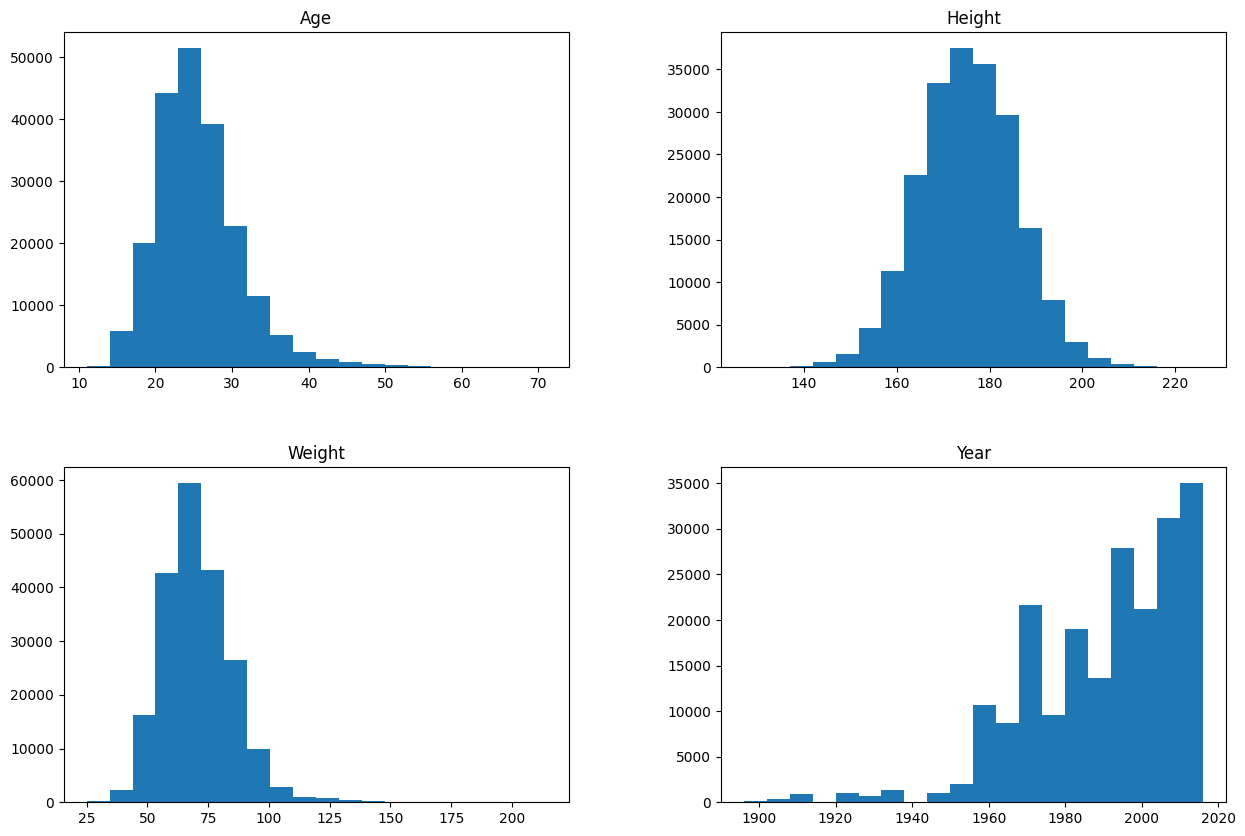

In [61]:
df.hist(bins=20, grid=False, figsize=(15,10));

,0
Age,"Axes(0.125,0.653529;0.227941x0.226471)"
Height,"Axes(0.398529,0.653529;0.227941x0.226471)"
Weight,"Axes(0.672059,0.653529;0.227941x0.226471)"
Year,"Axes(0.125,0.381765;0.227941x0.226471)"


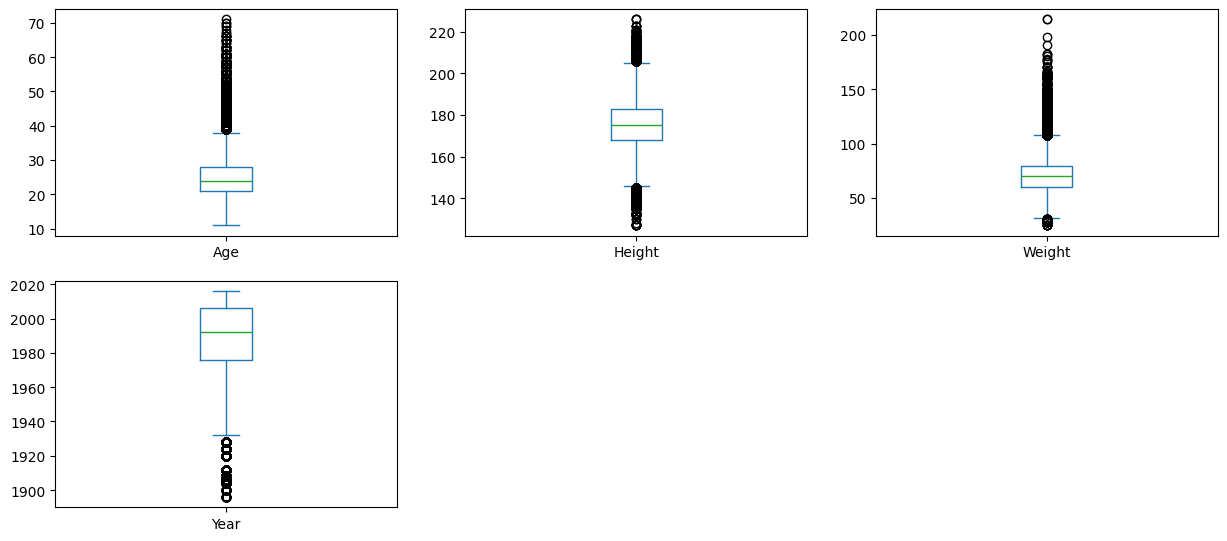

In [62]:
df.plot(kind='box', subplots=True, sharex=False, sharey=False, figsize=(15,10), layout=(3,3))

- Age, Height, Weight son variables normales
- Todas cuentan con valores atípicos

Haga análisis bivariados entre las variables de su dataset y la variable objetivo, e identifique que variables serían potencialmente buenas predictoras y cuales no.

Reporte sus resultados en una celda de texto.

In [70]:
# Correlación de las variables numericas
correlacion = df.select_dtypes(include='number').corr()['Weight'].sort_values(ascending=False)

print(correlacion)


Weight    1.000000
Height    0.796448
Age       0.211999
Year      0.022270
Name: Weight, dtype: float64


Buenas predictoras:

- Height, Age

## Procesamiento de las características y entrenamiento del modelo

Cree el matriz de características $X$ con todos las variables no descartadas de su dataframe, menos la variable **Weight**, que será su variable objetivo $y$.

Particione los datos en subconjuntos de entrenamiento y prueba, en un relacion 80/20, usando `random_state=1`.

Para una primera versión de su modelo, seleccione 5 características a procesar que, de acuerdo con el análisis exploratorio realizado, parezcan ser buenas predictoras. Dentro de las 5 debe haber al menos una característica ordinal y dos nominales.

Empaquete las transformaciones que aplicará a estas características usando `ColumnTransformer`. Use el parámetro `remainder='drop'`para descartar las variables que no va a procesar.

Para el modelado va a usar un modelo de regresión logística. Cree un flujo de trabajo que integre el procesamiento y el modelado usando `Pipeline`.

Entrene el modelo y reporte los scores de entrenamiento y de prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [71]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Weight'])
y = df['Weight']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.8)
print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (164676, 11)
Tamaño del conjunto de prueba es: (41170, 11)


Variables seleccionadas:

- Height: MinMaxScaler
- Age: MinMaxScaler
- Medal: OrdinalEncoder
- Sex, Season: OneHotEncoder

In [73]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler

ohe = OneHotEncoder(sparse_output=False, drop='if_binary')
ore = OrdinalEncoder(categories=[['No medal', 'Bronze', 'Silver', 'Gold']])
mm = MinMaxScaler()

preprocessor = ColumnTransformer(transformers=[
        ('ohe', ohe, ['Sex', 'Season']),
        ('ore', ore, ['Medal']),
        ('mm', mm, ['Height', 'Age'])
    ],
    remainder='drop')

preprocessor

ColumnTransformer(transformers=[('ohe',
                                 OneHotEncoder(drop='if_binary',
                                               sparse_output=False),
                                 ['Sex', 'Season']),
                                ('ore',
                                 OrdinalEncoder(categories=[['No medal',
                                                             'Bronze', 'Silver',
                                                             'Gold']]),
                                 ['Medal']),
                                ('mm', MinMaxScaler(), ['Height', 'Age'])])

In [75]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

clf = Ridge()

model = Pipeline([
    ('preprocessor', preprocessor),
     ('clf', clf)
    ])

model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe',
                                                  OneHotEncoder(drop='if_binary',
                                                                sparse_output=False),
                                                  ['Sex', 'Season']),
                                                 ('ore',
                                                  OrdinalEncoder(categories=[['No '
                                                                              'medal',
                                                                              'Bronze',
                                                                              'Silver',
                                                                              'Gold']]),
                                                  ['Medal']),
                                                 ('mm', MinMaxScaler(),
                                                  ['Height', 'Age'])])),
                ('clf', Ridge())])

In [76]:
model.fit(X_train, y_train)

print('Train score: ', model.score(X_train, y_train))
print('Test score: ', model.score(X_test, y_test))

Train score:  0.6640852854297021
Test score:  0.6574375616689419


In [77]:
model.named_steps['preprocessor'].get_feature_names_out()

array(['ohe__Sex_M', 'ohe__Season_Winter', 'ore__Medal', 'mm__Height',
       'mm__Age'], dtype=object)

Vuelva a entrenar el modelo, pero esta vez añada 2 características adicionales.

Reporte los scores de entrenamiento y de prueba del modelo reentrenado.

Reporte las características con las que **realmente** fue reentrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [78]:
preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', ohe, ['Sex', 'Season', 'Sport', 'City']),
        ('ore', ore, ['Medal']),
        ('mm', mm, ['Height', 'Age'])
    ],
    remainder='drop'
)

model = Pipeline([
    ('preprocessor', preprocessor),
     ('clf', clf)
    ])

model.fit(X_train, y_train)

print('Train score: ', model.score(X_train, y_train))
print('Test score: ', model.score(X_test, y_test))

Train score:  0.7323657430886061
Test score:  0.7252877306526124


Hay una mejora en la prediccion del modelo al añadir las variables cualitativas **"Sport"** y **"City"** (OneHotEncoder)

In [79]:
model.named_steps['preprocessor'].get_feature_names_out()

array(['ohe__Sex_M', 'ohe__Season_Winter', 'ohe__Sport_Alpine Skiing',
       'ohe__Sport_Archery', 'ohe__Sport_Art Competitions',
       'ohe__Sport_Athletics', 'ohe__Sport_Badminton',
       'ohe__Sport_Baseball', 'ohe__Sport_Basketball',
       'ohe__Sport_Beach Volleyball', 'ohe__Sport_Biathlon',
       'ohe__Sport_Bobsleigh', 'ohe__Sport_Boxing', 'ohe__Sport_Canoeing',
       'ohe__Sport_Cross Country Skiing', 'ohe__Sport_Curling',
       'ohe__Sport_Cycling', 'ohe__Sport_Diving',
       'ohe__Sport_Equestrianism', 'ohe__Sport_Fencing',
       'ohe__Sport_Figure Skating', 'ohe__Sport_Football',
       'ohe__Sport_Freestyle Skiing', 'ohe__Sport_Golf',
       'ohe__Sport_Gymnastics', 'ohe__Sport_Handball',
       'ohe__Sport_Hockey', 'ohe__Sport_Ice Hockey', 'ohe__Sport_Judo',
       'ohe__Sport_Lacrosse', 'ohe__Sport_Luge',
       'ohe__Sport_Modern Pentathlon', 'ohe__Sport_Motorboating',
       'ohe__Sport_Nordic Combined', 'ohe__Sport_Rhythmic Gymnastics',
       'ohe__Sport_Rowi